# CA2 - Demo

In this notebook, I will use my model to classify 10 example images in order to highlight its strengths and weaknesses.

Some of these example images were taken by me, while others were copied from the test set or downloaded from the web.

In [51]:
from keras.models import load_model
from keras.preprocessing import image_dataset_from_directory

import numpy as np
import matplotlib.pyplot as plt

## Load the Model and Images

In [52]:
import os
from google.colab import drive
drive.mount('/content/drive')
base_dir = "./drive/My Drive/Colab Notebooks/ca2"     #Edit this as necessary
examples_dir = os.path.join(base_dir, "examples")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
best_network = load_model(os.path.join(base_dir, "best_network.keras"))

In [54]:
examples = image_dataset_from_directory(directory=examples_dir, labels=None, shuffle=False, image_size=(256, 256), batch_size=None)

Found 10 files.


In [55]:
examples_array = np.array(list(examples))

## View the Images and Predictions

In [56]:
predictions = best_network.predict(examples_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


In [57]:
predictions

array([[1.],
       [1.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.]], dtype=float32)

In [58]:
def show_image_and_prediction(i):
  plt.imshow(np.array(examples_array[i]).astype("uint8"))
  plt.show()
  print(predictions[i])

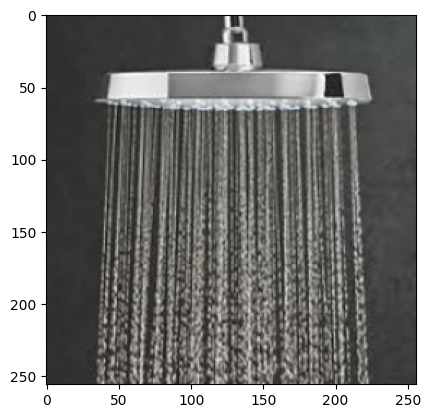

[1.]


In [59]:
show_image_and_prediction(0)

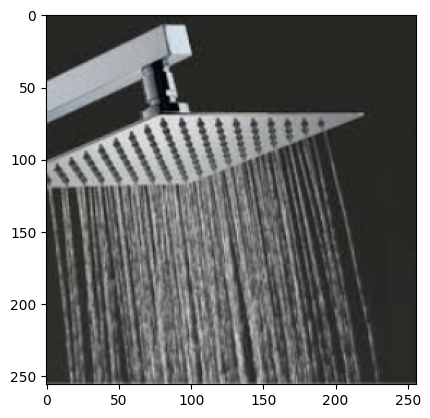

[1.]


In [60]:
show_image_and_prediction(1)

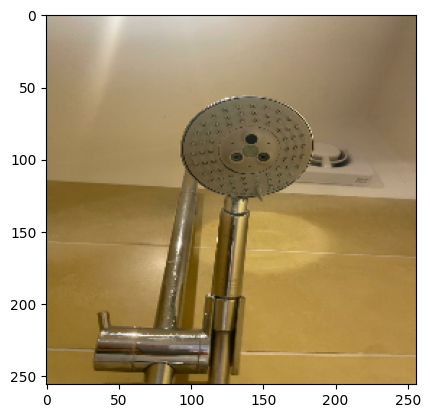

[1.]


In [61]:
show_image_and_prediction(2)

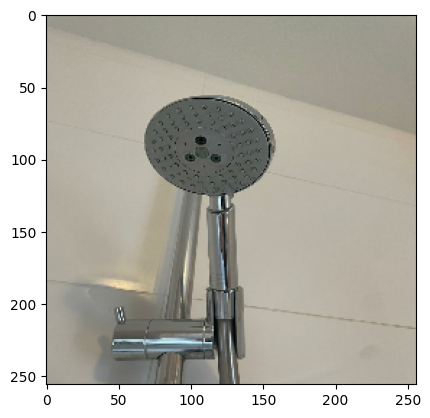

[1.]


In [62]:
show_image_and_prediction(3)

The model was able to correctly classify 4 images of showerheads. (2 from the test set, 2 taken by me).

The first two images show that the model can identify a showerhead even if the camera is not facing it straight on. These images also show that it can identify differently shaped showerheads.

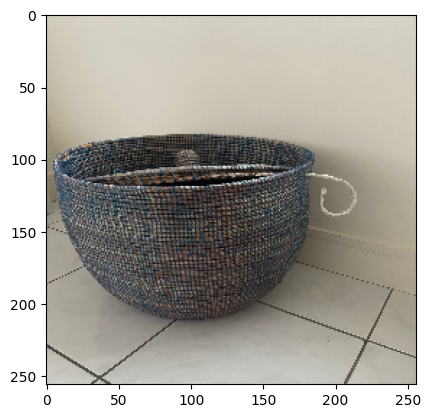

[0.]


In [63]:
show_image_and_prediction(4)

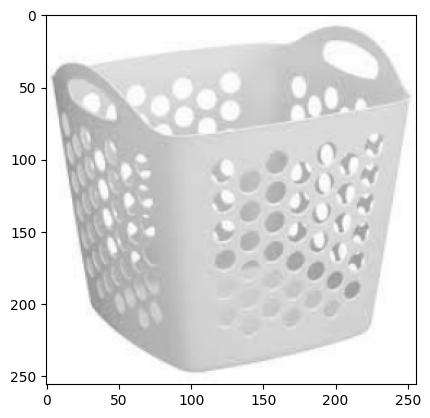

[0.]


In [64]:
show_image_and_prediction(5)

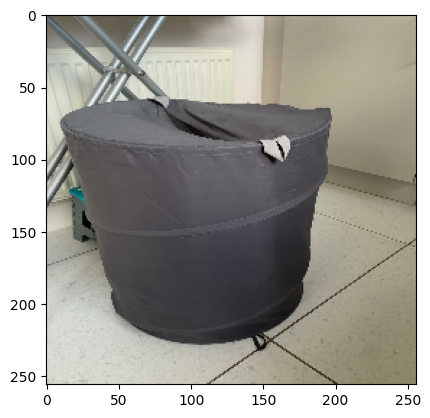

[0.]


In [65]:
show_image_and_prediction(6)

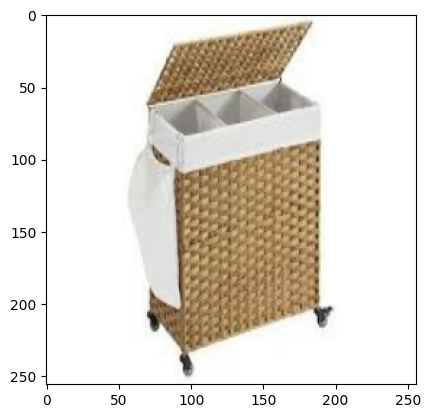

[0.]


In [66]:
show_image_and_prediction(7)

The model was also able to correctly identify 4 images of laundry baskets (once again, 2 from the test set, 2 taken by me).

It was able to identify many different kinds of baskets, with different shapes, sizes and structures.

Before we get too excited, let's consider if the model has learned any shortcuts.

I tried to guess how the model identifies showerheads and I thought it might have been the nozzles/holes in the head. The model may be using the presence of several small circles/dots as a sign of a showerhead.

To test this, I got the model to classify an image that is neither a showerhead nor a laundry basket, but simply consists of many small dots.

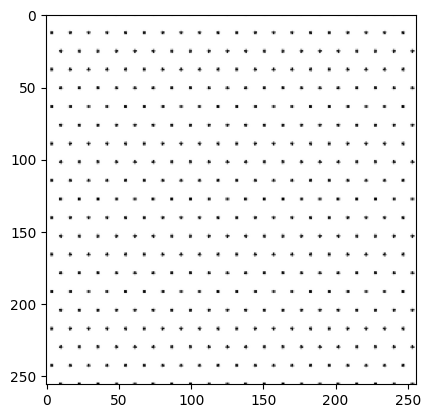

[1.]


In [67]:
show_image_and_prediction(8)

The model is fully confident this is a showerhead.

Of course, this image does not actually fall into the classes the model is trained on, so it can't really be faulted for this. However, this does lend some credibility to my theory.

Now I will give the model an image of a laundry basket with many small dots on it.

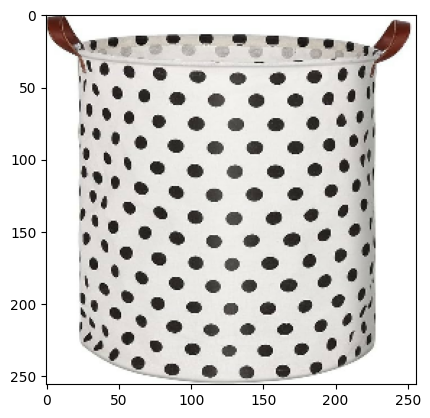

[1.]


In [68]:
show_image_and_prediction(9)

The model has incorrectly indentified this as a showerhead, suggesting it has in fact learned a shortcut of "many circles = showerhead".

This shows that, despite its 100% accuracy on the test set, the model is not infallible.

## Strengths and Weaknesses

In addition to the very high accuracy, one of the model's biggest strengths is that it can handle diversity in the images. It can recognise laundry baskets and showerheads of many different shapes and sizes. It does not matter if a basket has handles or holes, or what it is made of. The model can correctly classify wide varieties of these objects, and is not limited to any particular kind.

Its biggest weakness appears to be the shortcut it has learned to identify showerheads. The final image has almost nothing in common with showerheads apart from having many circles, yet the model gives it a 100% probability of being a showerhead. This suggests it is overreliant on a particular feature and may not have learned a wide selection of features to identify showerheads.

Despite this flaw, the model still has a very high accuracy. I feel the model is still very strong, and I would choose to deploy it.